Removing: ['model_ EcoSport', 'model_ Escort', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ Mondeo', 'model_ Ranger', 'model_ Streetka', 'model_ Tourneo Connect', 'model_ Transit Tourneo', 'model_Focus', 'fuelType_Electric', 'fuelType_Other']


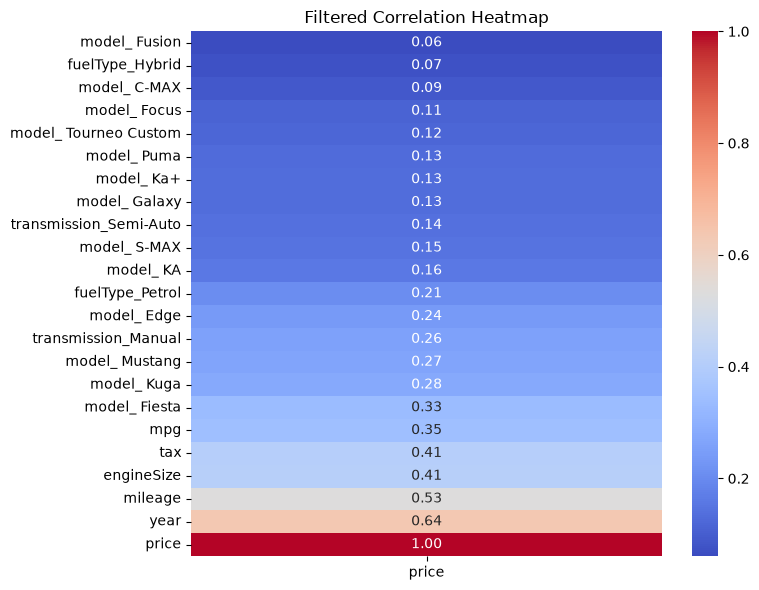

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# ============================================
# STEP 1: Load Data
# ============================================
df = pd.read_csv("ford.csv")
print(df.head())

# ============================================
# STEP 2: Lemmatization on description column
# ============================================
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

df['description'] = df['description'].apply(lemmatize_text)

# ============================================
# STEP 3: TF-IDF on description
# ============================================
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['description'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

# ============================================
# STEP 4: Drop description, concat tfidf
# ============================================
df_no_desc = df.drop(columns=['description'])
df_final = pd.concat([df_no_desc, tfidf_df], axis=1)

print("Shape:", df_final.shape)

# ============================================
# STEP 5: One-Hot Encoding (categorical cols)
# ============================================
df_encoded = pd.get_dummies(df_final, drop_first=True)

# ============================================
# STEP 6: Correlation Heatmap
# ============================================
corr = df_encoded.corr()['price'].abs()

# Low correlation columns remove karo
col_to_remove = corr[corr < 0.05].index.tolist()
if 'price' in col_to_remove:
    col_to_remove.remove('price')

df_encoded = df_encoded.drop(columns=col_to_remove)

# Updated correlation
corr_filtered = df_encoded.corr()['price'].abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered.to_frame(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap with Price")
plt.tight_layout()
plt.show()

# ============================================
# STEP 7: Model Training
# ============================================
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))